In [208]:
'''
prompt:
Escreva codigo python que le todos os arquivos CSV disponiveis na pasta data/model-runs. 
O nome de cada arquivo CSV está no formato gemini-2.5-flash_answers.csv, em que tudo que vem antes de  "_answers.csv" é o nome do modelo. 

Leia cada arquivo CSV com o pandas. 
Cada linha do arquivo é uma questão da OAB que o modelo resolveu. 
Calcule o número de respostas certas comparando se "alternativa" == "correct". 
Crie um df em que cada row é um modelo, com a nota total e a nota percentual.

'''

import pandas as pd
import os
import glob
import re

# Caminho da pasta com os arquivos CSV
folder_path = '../data/processed/model-runs/'
csv_files = glob.glob(os.path.join(folder_path, '*_answers_irac*.csv'))

# Lista para guardar os resultados de cada modelo
model_results = []

for filepath in csv_files:
    # Extrai o nome do modelo a partir do nome do arquivo
    filename = os.path.basename(filepath)
    match = re.match(r'(.+)_answers_irac-(.*)\.csv$', filename)
    if match:
        model_name = match.group(1)
        irac = match.group(2)


    # Lê o CSV com pandas
    df = pd.read_csv(filepath)

    # Garante que as colunas esperadas estão presentes
    if 'alternativa' not in df.columns or 'correct' not in df.columns:
        print(f"Aviso: arquivo {filename} não contém as colunas esperadas.")
        continue

    # Conta quantas respostas estão corretas
    total_questions = len(df)
    correct_answers = (df['alternativa'] == df['correct']).sum()
    percentage = correct_answers / total_questions * 100

    # Adiciona os resultados à lista
    model_results.append({
        'modelo': model_name,
        'irac': irac,
        'questões': total_questions,
        'acertos': correct_answers,
        'percentual': round(percentage, 2)
    })

# Cria um DataFrame com os resultados
results_df = pd.DataFrame(model_results)

# Ordena do maior para o menor percentual de acertos
results_df = results_df.sort_values(by='percentual', ascending=False)

results_df.head(20)


,modelo,irac,questões,acertos,percentual
5,gemini-2.5-pro,____,70,66,94.29
4,gemini-2.5-flash,____,80,70,87.50
2,gemini-2.0-flash,____,80,62,77.50
3,gemini-2.5-flash-lite-preview-06-17,____,80,54,67.50
1,gemini-1.5-flash,____,30,20,66.67
0,gemini-1.5-flash-8b,____,50,29,58.00


In [222]:
import pandas as pd
import os
import glob
import re
import json

# Caminho da pasta com os arquivos CSV
folder_path = '../data/processed/model-runs/'
csv_files = glob.glob(os.path.join(folder_path, '*_answers_irac*.csv'))

# Lista para guardar todos os dados juntos
all_data = []

for filepath in csv_files:
    # Extrai o nome do modelo a partir do nome do arquivo
    filename = os.path.basename(filepath)
    match = re.match(r'(.+)_answers_irac-(.*)\.csv$', filename)
    if match:
        model_name = match.group(1)
        irac = match.group(2)

    # Lê o CSV com pandas
    df = pd.read_csv(filepath)

    # Garante que as colunas esperadas estão presentes
    if not {'alternativa', 'correct', 'question_id'}.issubset(df.columns):
        print(f"Aviso: arquivo {filename} não contém as colunas esperadas.")
        continue

    # Adiciona colunas de metadados
    df['modelo'] = model_name
    df['irac'] = irac
    df['acertou'] = df['alternativa'] == df['correct']

    # Armazena os dados
    all_data.append(df)

# Junta todos os dados em um único DataFrame
full_df = pd.concat(all_data, ignore_index=True)

# Calcula a acurácia e média de rule_count por question_id
accuracy_by_question_df = (
    full_df.groupby('question_id', as_index=False)
    .agg(acurácia=('acertou', 'mean'), rule_count=('rule_count', 'mean'))
)

# Calcula proporção de cada alternativa por questão
alternativa_props = (
    full_df.groupby(['question_id', 'alternativa'])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
    .unstack(fill_value=0)
)

# Renomeia colunas de alternativas para deixar claro que são proporções
alternativa_props.columns = [f"prop_{col}" for col in alternativa_props.columns]

# Garante que question_id seja coluna
alternativa_props = alternativa_props.reset_index()

# Junta tudo no mesmo DataFrame
final_df = accuracy_by_question_df.merge(alternativa_props, on='question_id', how='left')

# Ordena pela acurácia
final_df = final_df.sort_values(by='acurácia', ascending=False)

# Mostra as 100 primeiras
final_df.head(100)
import pandas as pd
import os
import glob
import re
import json

# Caminho da pasta com os arquivos CSV
folder_path = '../data/processed/model-runs/'
csv_files = glob.glob(os.path.join(folder_path, '*_answers_irac*.csv'))

# Lista para guardar todos os dados juntos
all_data = []

for filepath in csv_files:
    # Extrai o nome do modelo a partir do nome do arquivo
    filename = os.path.basename(filepath)
    match = re.match(r'(.+)_answers_irac-(.*)\.csv$', filename)
    if match:
        model_name = match.group(1)
        irac = match.group(2)

    # Lê o CSV com pandas
    df = pd.read_csv(filepath)

    # Garante que as colunas esperadas estão presentes
    if not {'alternativa', 'correct', 'question_id'}.issubset(df.columns):
        print(f"Aviso: arquivo {filename} não contém as colunas esperadas.")
        continue

    # Adiciona colunas de metadados
    df['modelo'] = model_name
    df['irac'] = irac
    df['acertou'] = df['alternativa'] == df['correct']

    # Armazena os dados
    all_data.append(df)

# Junta todos os dados em um único DataFrame
full_df = pd.concat(all_data, ignore_index=True)

# Calcula a acurácia e média de rule_count por question_id
accuracy_by_question_df = (
    full_df.groupby('question_id', as_index=False)
    .agg(acurácia=('acertou', 'mean'), rule_count=('rule_count', 'mean'))
)

# Calcula proporção de cada alternativa por questão
alternativa_props = (
    full_df.groupby(['question_id', 'alternativa'])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
    .unstack(fill_value=0)
)

# Renomeia colunas de alternativas para deixar claro que são proporções
alternativa_props.columns = [f"prop_{col}" for col in alternativa_props.columns]

# Garante que question_id seja coluna
#alternativa_props = alternativa_props.reset_index()

# Junta tudo no mesmo DataFrame
final_df = accuracy_by_question_df.merge(alternativa_props, on='question_id', how='left')

# Ordena pela acurácia
final_df = final_df.sort_values(by='acurácia', ascending=False)

# Mostra as 100 primeiras
final_df.head(100)


ValueError: cannot insert question_id, already exists

<Figure size 1000x600 with 0 Axes>

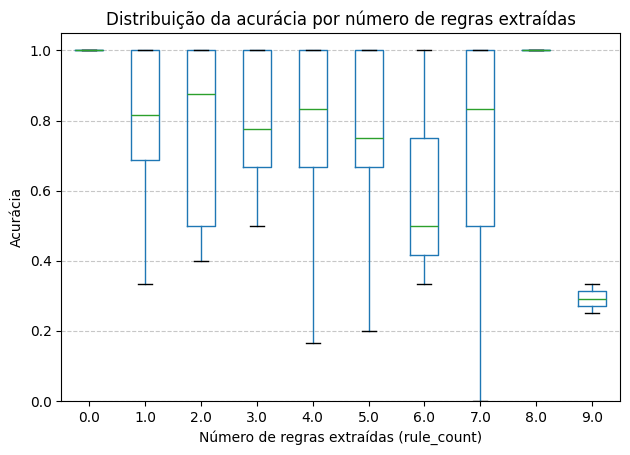

In [210]:
import matplotlib.pyplot as plt

# Plot de boxplot diretamente a partir do DataFrame original
plt.figure(figsize=(10, 6))
accuracy_by_question_df.boxplot(
    column='acurácia',
    by='rule_count',
    grid=False,
    showfliers=False  # oculta outliers, opcional
)

plt.xlabel('Número de regras extraídas (rule_count)')
plt.ylabel('Acurácia')
plt.title('Distribuição da acurácia por número de regras extraídas')
plt.suptitle('')  # Remove o título automático extra do pandas
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
